# 03 · Feature Selection
Confirm which signals matter, prune redundancy. We use a fast model + permutation importance (model-agnostic) and a correlation scan.

In [1]:
# Make `src` importable when running from the notebooks/ folder
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
pd.set_option('display.max_columns', 60)

In [2]:
from src.data_loader import load_raw
from src.cleaning import prepare_target, clean_features
from src.feature_engineering import add_features
from src.preprocessing import make_pipeline
from src import config, explain
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
df = prepare_target(load_raw()).sample(20000, random_state=0)
y = df[config.TARGET].to_numpy(); X = df.drop(columns=[config.TARGET])
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.25,stratify=y,random_state=0)
pipe = make_pipeline(HistGradientBoostingClassifier(class_weight='balanced',random_state=0)).fit(Xtr,ytr)

In [3]:
imp = explain.global_importance(pipe, Xte, yte, n_repeats=5, max_samples=4000)
imp.head(15)

,feature,importance,std
0,location,0.173046,0.008413
1,interest_rate,0.060372,0.003110
2,job,0.047121,0.002379
3,loan_amount,0.020587,0.001821
4,age,0.019099,0.001818
5,number_of_defaults,0.014529,0.001801
6,marital_status,0.004973,0.001337
7,remaining term,0.002639,0.002940
8,salary,0.002498,0.002318
9,gender,0.000930,0.000607


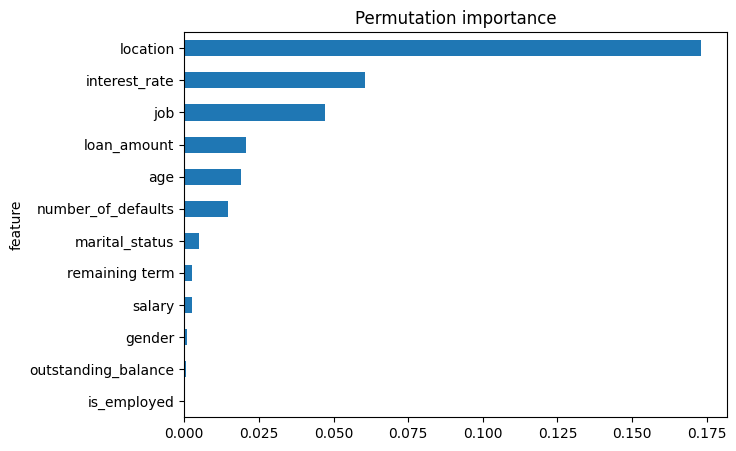

In [4]:
import matplotlib.pyplot as plt
imp.head(12).set_index('feature')['importance'].plot.barh(figsize=(7,5)); plt.gca().invert_yaxis(); plt.title('Permutation importance');

## Correlation among engineered numerics
Drop one of any pair that is near-perfectly correlated to reduce redundancy.

In [5]:
feats = add_features(clean_features(df))
feats[config.NUMERIC_FEATURES].corr().round(2)

,loan_amount,outstanding_balance,interest_rate,age,number_of_defaults,remaining_term,salary,is_employed,monthly_rate,estimated_monthly_payment,total_repayment_est,interest_cost_est,interest_cost_ratio,dti,loan_to_income,balance_to_income,balance_to_loan,balance_minus_loan,interest_burden,has_prior_default,defaults_per_decade,is_high_interest,is_urban,is_stable_job,is_risky_job,job_risk_score,marital_risk_score,amount_x_rate,rate_x_term,dti_x_defaults,lti_x_defaults,log_loan_amount,log_salary,log_outstanding_balance,log_estimated_monthly_payment,log_interest_cost_est,log_loan_to_income,loan_month,loan_quarter,loan_week,loan_dayofweek,loan_is_month_end,loan_is_quarter_end,month_sin,month_cos,quarter_sin,quarter_cos,dow_sin,dow_cos,job_missing,location_missing,marital_status_missing,remaining_term_missing,total_missing_fields
loan_amount,1.00,0.57,0.24,0.02,-0.02,0.03,0.54,-0.05,0.24,0.79,0.98,0.86,0.11,0.47,0.80,0.13,-0.53,-0.77,0.58,-0.02,-0.02,0.17,-0.01,-0.07,0.05,-0.01,-0.02,0.98,0.11,0.41,0.55,0.87,0.54,0.56,0.85,0.80,0.81,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.01,0.01,0.01,-0.01,0.01,0.05,-0.03,0.01,NaN,0.04
outstanding_balance,0.57,1.00,0.15,0.02,-0.01,0.01,0.33,-0.04,0.15,0.45,0.55,0.48,0.06,0.27,0.46,0.61,-0.24,0.09,0.96,-0.01,-0.02,0.10,0.00,-0.03,0.02,-0.01,-0.01,0.56,0.06,0.22,0.31,0.55,0.33,0.98,0.53,0.50,0.51,-0.00,-0.01,-0.01,0.00,-0.01,-0.00,0.01,-0.00,0.01,-0.00,-0.01,0.00,0.04,-0.02,0.00,NaN,0.02
interest_rate,0.24,0.15,1.00,0.04,-0.04,0.05,0.24,0.01,1.00,0.22,0.29,0.36,0.40,0.12,0.15,-0.04,-0.22,-0.17,0.42,-0.04,-0.05,0.76,0.02,0.02,-0.01,-0.01,0.17,0.37,0.40,0.09,0.09,0.28,0.24,0.16,0.31,0.40,0.22,0.01,0.01,0.01,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.01,-0.01,-0.04,-0.00,NaN,-0.02
age,0.02,0.02,0.04,1.00,-0.03,-0.05,-0.20,-0.14,0.04,0.03,0.00,-0.02,-0.04,0.08,0.15,0.16,-0.07,-0.01,0.02,-0.03,-0.11,0.00,0.02,-0.10,0.04,0.08,-0.30,0.01,-0.04,0.06,0.08,0.07,-0.18,0.03,0.08,0.05,0.17,0.01,0.01,0.01,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.01,0.14,-0.02,0.01,NaN,0.10
number_of_defaults,-0.02,-0.01,-0.04,-0.03,1.00,-0.00,-0.01,-0.02,-0.04,-0.02,-0.02,-0.02,-0.01,-0.01,-0.02,-0.00,0.03,0.01,-0.02,0.92,0.99,-0.03,-0.02,0.00,-0.01,-0.00,-0.00,-0.02,-0.01,0.42,0.62,-0.03,-0.02,-0.01,-0.03,-0.03,-0.03,-0.01,-0.01,-0.01,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.01,-0.00,0.00,0.02,0.03,-0.00,NaN,0.02
remaining_term,0.03,0.01,0.05,-0.05,-0.00,1.00,0.72,0.02,0.05,-0.23,0.21,0.45,0.93,-0.43,-0.38,-0.59,-0.02,-0.03,0.03,-0.01,-0.00,0.03,0.00,0.00,0.01,-0.01,0.03,0.04,0.93,-0.34,-0.25,0.04,0.74,0.01,-0.18,0.39,-0.30,-0.01,-0.01,-0.01,0.00,0.00,0.00,0.01,0.00,0.01,-0.00,-0.01,0.01,-0.02,0.00,0.02,NaN,-0.00
salary,0.54,0.33,0.24,-0.20,-0.01,0.72,1.00,0.06,0.24,0.21,0.69,0.84,0.76,-0.15,0.03,-0.46,-0.34,-0.40,0.37,-0.02,-0.00,0.18,0.00,-0.01,0.04,-0.04,0.06,0.55,0.76,-0.12,0.02,0.53,0.98,0.34,0.37,0.75,0.18,-0.01,-0.01,-0.01,0.00,-0.01,-0.00,0.01,0.01,0.01,0.00,-0.01,0.01,-0.06,-0.02,0.02,NaN,-0.04
is_employed,-0.05,-0.04,0.01,-0.14,-0.02,0.02,0.06,1.00,0.01,-0.04,-0.04,-0.03,0.03,-0.05,-0.10,-0.08,0.03,0.03,-0.03,-0.01,-0.01,-0.00,0.02,0.28,0.14,-0.26,0.01,-0.04,0.03,-0.05,-0.08,-0.06,0.05,-0.04,-0.06,-0.04,-0.10,0.01,0.01,0.01,0.00,-0.01,-0.01,-0.01,0.00,-0.01,0.00,0.00,-0.01,-1.00,-0.01,-0.01,NaN,-0.72
monthly_rate,0.24,0.15,1.00,0.04,-0.04,0.05,0.24,0.01,1.00,0.22,0.29,0.36,0.40,0.12,0.15,-0.04,-0.22,-0.17,0.42,-0.04,-0.05,0.76,0.02,0.02,-0.01,-0.01,0.17,0.37,0.40,0.09,0.09,0.28,0.24,0.16,0.31,0.40,0.22,0.01,0.01,0.01,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.01,-0.01,-0.04,-0.00,NaN,-0.02
estimated_monthly_payment,0.79,0.45,0.22,0.03,-0.02,-0.23,0.21,-0.04,0.22,1.00,0.71,0.54,-0.15,0.86,0.88,0.40,-0.41,-0.61,0.47,-0.02,-0.02,0.16,-0.01,-0.05,0.03,-0.01,-0.01,0.78,-0.13,0.67,0.59,0.69,0.17,0.45,0.75,0.49,0.75,0.01,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.00,0.04,-0.02,0.00,NaN,0.02


## Adversarial validation — pruning features that overfit on *real* data
We relabel rows **0 = train period / 1 = future** (by disbursement date) and train a classifier to tell them apart. If it can (AUC ≫ 0.5), those populations differ and the high-`drift_importance` features will overfit to the past and rot in production. This is *why* we excluded absolute-time features (`loan_year`, `loan_dayofyear`) from the model.

In [6]:
from src import feature_selection as fs
adv = fs.adversarial_validation(X, holdout_frac=0.25, split='temporal')
print('adversarial AUC = %.3f' % adv['adversarial_auc'])
print(adv['verdict'])
adv['drift_importance'].head(10)

C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


...

C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


adversarial AUC = 0.497
No meaningful drift (AUC~0.5): train and future look alike.


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['loan_month' 'loan_quarter' 'loan_week' 'loan_dayofweek' 'month_sin'
 'month_cos' 'quarter_sin' 'quarter_cos' 'dow_sin' 'dow_cos']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,drift_importance
0,loan_amount,0.248793
1,salary,0.187395
2,outstanding_balance,0.154559
3,location,0.143760
4,interest_rate,0.128137
5,remaining term,0.108730
6,job,0.070371
7,number_of_defaults,0.035692
8,marital_status,0.020259
9,age,0.020015


> AUC ≈ 0.5 here ⇒ no covariate shift across time in this dataset (good — the split is stable). If a feature *did* drift, it would top `drift_importance` and we'd drop or re-engineer it. The same machinery runs post-deployment as PSI in `notebook 11`.

> Net rule: keep features with non-trivial importance, prune one of any |r|>0.95 pair, and drop anything with high adversarial drift. Final feature lists live in `src/config.py`.